In [2]:
import pandas as pd

input_file = "./Datasets/Final_Dataset.csv"
df = pd.read_csv(input_file)

# Reconstruct timestamp
df["_Timestamp"] = pd.to_datetime(
    df["Day"].astype(str).str.zfill(2) + "-" +
    df["Month"].astype(str).str.zfill(2) + "-" +
    df["Year"].astype(str) + " " +
    df["Time"].astype(str),
    format="%d-%m-%Y %H:%M:%S"
)

def split_by_year(data, target_col, horizon_hours):
    # Remove rows where the target is missing
    data = data.dropna(subset=[target_col]).copy()

    # Ensure the target falls within the same split period
    target_time = data["_Timestamp"] + pd.Timedelta(hours=horizon_hours)

    train = data[
        (data["_Timestamp"].dt.year.between(2020, 2023)) &
        (target_time < pd.Timestamp("2024-01-01"))
    ].copy()

    val = data[
        (data["_Timestamp"].dt.year == 2024) &
        (target_time < pd.Timestamp("2025-01-01"))
    ].copy()

    test = data[
        (data["_Timestamp"].dt.year == 2025) &
        (target_time < pd.Timestamp("2026-01-01"))
    ].copy()

    return train, val, test


# +1 hour prediction
train_1, val_1, test_1 = split_by_year(
    df, "AQI_future_1", 1
)

# +24 hour prediction
train_24, val_24, test_24 = split_by_year(
    df, "AQI_future_24", 24
)

# Check split sizes
print("+1 Hour:")
print("Train:", len(train_1))
print("Validation:", len(val_1))
print("Test:", len(test_1))

print("\n+24 Hours:")
print("Train:", len(train_24))
print("Validation:", len(val_24))
print("Test:", len(test_24))

C:\Users\tanki\AppData\Local\Temp\ipykernel_50416\3289888801.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["_Timestamp"] = pd.to_datetime(


+1 Hour:
Train: 1163157
Validation: 354573
Test: 188375

+24 Hours:
Train: 1154267
Validation: 353502
Test: 187575


In [3]:
df["_Timestamp"] = pd.to_datetime(
    df["Day"].astype(str).str.zfill(2) + "-" +
    df["Month"].astype(str).str.zfill(2) + "-" +
    df["Year"].astype(str) + " " +
    df["Time"].astype(str),
    format="%d-%m-%Y %H:%M:%S"
)

df = df.copy()

In [4]:
for name, splits, horizon in [
    ("+1h", (train_1, val_1, test_1), 1),
    ("+24h", (train_24, val_24, test_24), 24)
]:
    print(f"\n{name} boundary check:")

    for split_name, split_df in zip(
        ["Train", "Validation", "Test"], splits
    ):
        target_time = (
            split_df["_Timestamp"] +
            pd.Timedelta(hours=horizon)
        )

        print(
            f"{split_name}: "
            f"{split_df['_Timestamp'].min()} to "
            f"{split_df['_Timestamp'].max()} | "
            f"Target ends: {target_time.max()}"
        )


+1h boundary check:
Train: 2020-01-02 00:00:00 to 2023-12-31 22:00:00 | Target ends: 2023-12-31 23:00:00
Validation: 2024-01-01 00:00:00 to 2024-12-30 23:00:00 | Target ends: 2024-12-31 00:00:00
Test: 2025-01-01 00:00:00 to 2025-12-30 23:00:00 | Target ends: 2025-12-31 00:00:00

+24h boundary check:
Train: 2020-01-02 00:00:00 to 2023-12-30 23:00:00 | Target ends: 2023-12-31 23:00:00
Validation: 2024-01-01 00:00:00 to 2024-12-30 23:00:00 | Target ends: 2024-12-31 23:00:00
Test: 2025-01-01 00:00:00 to 2025-12-30 23:00:00 | Target ends: 2025-12-31 23:00:00


In [5]:
# Display all columns
print("Total columns:", len(df.columns))

for i, col in enumerate(df.columns, 1):
    print(f"{i:3}. {col}")

# Find likely weather-related columns
weather_keywords = [
    "temp", "humidity", "wind", "pressure",
    "solar", "rain", "precip", "radiation"
]

weather_candidates = [
    col for col in df.columns
    if any(keyword in col.lower() for keyword in weather_keywords)
]

print("\nLikely weather columns:")
print(weather_candidates)

# Check target and helper columns
print("\nTarget/helper columns:")
print([
    col for col in df.columns
    if "future" in col.lower()
    or col == "_Timestamp"
])

Total columns: 133
  1. Day
  2. Month
  3. Year
  4. Time
  5. Day_of_Week
  6. Season
  7. PM2.5 (µg/m³)
  8. PM10 (µg/m³)
  9. NO2 (µg/m³)
 10. SO2 (µg/m³)
 11. CO (mg/m³)
 12. Ozone (µg/m³)
 13. NH3 (µg/m³)
 14. temperature_2m (°C)
 15. relative_humidity_2m (%)
 16. dew_point_2m (°C)
 17. precipitation (mm)
 18. surface_pressure (hPa)
 19. wind_speed_10m (km/h)
 20. wind_direction_10m (°)
 21. shortwave_radiation (W/m²)
 22. cloud_cover (%)
 23. elevation
 24. latitude
 25. longitude
 26. AQI
 27. AQI_lag_1
 28. AQI_lag_6
 29. AQI_lag_12
 30. AQI_lag_24
 31. PM2.5_lag_1
 32. PM2.5_lag_6
 33. PM2.5_lag_12
 34. PM2.5_lag_24
 35. PM10_lag_1
 36. PM10_lag_6
 37. PM10_lag_12
 38. PM10_lag_24
 39. NO2_lag_1
 40. NO2_lag_6
 41. NO2_lag_12
 42. NO2_lag_24
 43. SO2_lag_1
 44. SO2_lag_6
 45. SO2_lag_12
 46. SO2_lag_24
 47. CO_lag_1
 48. CO_lag_6
 49. CO_lag_12
 50. CO_lag_24
 51. Ozone_lag_1
 52. Ozone_lag_6
 53. Ozone_lag_12
 54. Ozone_lag_24
 55. NH3_lag_1
 56. NH3_lag_6
 57. NH3_lag_12
 5

In [14]:

# -----------------------------
# 1. Define feature groups
# -----------------------------

weather_cols = [
    "temperature_2m (°C)",
    "relative_humidity_2m (%)",
    "dew_point_2m (°C)",
    "precipitation (mm)",
    "surface_pressure (hPa)",
    "wind_speed_10m (km/h)",
    "wind_direction_10m (°)",
    "shortwave_radiation (W/m²)",
    "cloud_cover (%)"
]

location_cols = [
    "elevation",
    "latitude",
    "longitude"
]

# Exclude helper and target columns
excluded_cols = [
    "Time",
    "AQI_future_1",
    "AQI_future_24",
    "_Timestamp"
]


# Convert Time to numeric hour
if "Hour" not in df.columns:
    df["Hour"] = pd.to_datetime(
        df["Time"], format="%H:%M:%S"
    ).dt.hour

# One-hot encode Season only if it still exists
if "Season" in df.columns:
    df = pd.get_dummies(
        df,
        columns=["Season"],
        prefix="Season",
        dtype=int
    )

print("Season columns:", [
    col for col in df.columns if col.startswith("Season_")
])


# -----------------------------
# 2. Create Model A and B features
# -----------------------------

common_cols = [
    col for col in df.columns
    if col not in weather_cols + excluded_cols
]

# Model A: without weather
features_A = common_cols

# Model B: with weather
features_B = common_cols + weather_cols

print("Model A features:", len(features_A))
print("Model B features:", len(features_B))

# Recreate splits using the transformed df
train_1, val_1, test_1 = split_by_year(
    df, "AQI_future_1", 1
)

train_24, val_24, test_24 = split_by_year(
    df, "AQI_future_24", 24
)

# -----------------------------
# 3. Prepare datasets per horizon
# -----------------------------

# +1 hour
X_train_A_1 = train_1[features_A]
X_val_A_1   = val_1[features_A]
X_test_A_1  = test_1[features_A]

X_train_B_1 = train_1[features_B]
X_val_B_1   = val_1[features_B]
X_test_B_1  = test_1[features_B]

y_train_1 = train_1["AQI_future_1"]
y_val_1   = val_1["AQI_future_1"]
y_test_1  = test_1["AQI_future_1"]


# +24 hours
X_train_A_24 = train_24[features_A]
X_val_A_24   = val_24[features_A]
X_test_A_24  = test_24[features_A]

X_train_B_24 = train_24[features_B]
X_val_B_24   = val_24[features_B]
X_test_B_24  = test_24[features_B]

y_train_24 = train_24["AQI_future_24"]
y_val_24   = val_24["AQI_future_24"]
y_test_24  = test_24["AQI_future_24"]

Season columns: ['Season_Autumn', 'Season_Monsoon', 'Season_Post-monsoon', 'Season_Summer', 'Season_Winter']
Model A features: 125
Model B features: 134


In [15]:
# Check feature columns
for name, features in [
    ("Model A", features_A),
    ("Model B", features_B)
]:
    print(f"\n{name}")

    # Missing columns
    missing = [col for col in features if col not in df.columns]
    print("Missing columns:", missing)

    # Non-numeric columns
    non_numeric = df[features].select_dtypes(
        exclude=["number", "bool"]
    ).columns.tolist()
    print("Non-numeric columns:", non_numeric)

    # Leakage check
    leakage = [
        col for col in features
        if "future" in col.lower() or col == "_Timestamp"
    ]
    print("Potential leakage columns:", leakage)


Model A
Missing columns: []
Non-numeric columns: ['Day_of_Week']
Potential leakage columns: []

Model B
Missing columns: []
Non-numeric columns: ['Day_of_Week']
Potential leakage columns: []


In [17]:
df = pd.get_dummies(
    df,
    columns=["Day_of_Week"],
    prefix="Day",
    dtype=int
)

print([
    col for col in df.columns
    if col.startswith("Day_")
])

['Day_Friday', 'Day_Monday', 'Day_Saturday', 'Day_Sunday', 'Day_Thursday', 'Day_Tuesday', 'Day_Wednesday']


In [22]:
import numpy as np

df["Hour"] = pd.to_datetime(df["Time"], format="%H:%M:%S").dt.hour

In [28]:
weather_cols = [
    "temperature_2m (°C)",
    "relative_humidity_2m (%)",
    "dew_point_2m (°C)",
    "precipitation (mm)",
    "surface_pressure (hPa)",
    "wind_speed_10m (km/h)",
    "wind_direction_10m (°)",
    "shortwave_radiation (W/m²)",
    "cloud_cover (%)"
]

excluded_cols = [
    "Time",
    "_Timestamp",
    "AQI_future_1",
    "AQI_future_24"
]

common_cols = [
    col for col in df.columns
    if col not in weather_cols + excluded_cols
]

features_A = common_cols
features_B = common_cols + weather_cols

print("Model A features:", len(features_A))
print("Model B features:", len(features_B))

Model A features: 131
Model B features: 140


In [29]:
train_1, val_1, test_1 = split_by_year(df, "AQI_future_1", 1)
train_24, val_24, test_24 = split_by_year(df, "AQI_future_24", 24)

In [30]:
X_train_1_A = train_1[features_A]
X_val_1_A   = val_1[features_A]
X_test_1_A  = test_1[features_A]

X_train_1_B = train_1[features_B]
X_val_1_B   = val_1[features_B]
X_test_1_B  = test_1[features_B]

y_train_1 = train_1["AQI_future_1"]
y_val_1   = val_1["AQI_future_1"]
y_test_1  = test_1["AQI_future_1"]

In [33]:
X_train_24_A = train_24[features_A]
X_val_24_A   = val_24[features_A]
X_test_24_A  = test_24[features_A]

X_train_24_B = train_24[features_B]
X_val_24_B   = val_24[features_B]
X_test_24_B  = test_24[features_B]

y_train_24 = train_24["AQI_future_1"]
y_val_24   = val_24["AQI_future_1"]
y_test_24  = test_24["AQI_future_1"]

In [34]:
# Check feature columns
for name, features in [("Model A", features_A), ("Model B", features_B)]:
    non_numeric = df[features].select_dtypes(exclude="number").columns.tolist()

    print(f"\n{name}")
    print("Feature count:", len(features))
    print("Non-numeric columns:", non_numeric)
    print("Contains Time:", "Time" in features)
    print("Contains Hour:", "Hour" in features)
    print("Contains target:", any(col.startswith("AQI_future") for col in features))


Model A
Feature count: 131
Non-numeric columns: []
Contains Time: False
Contains Hour: True
Contains target: False

Model B
Feature count: 140
Non-numeric columns: []
Contains Time: False
Contains Hour: True
Contains target: False


In [35]:
# 24-hour target inputs
X_train_24_A = train_24[features_A]
X_val_24_A   = val_24[features_A]
X_test_24_A  = test_24[features_A]

X_train_24_B = train_24[features_B]
X_val_24_B   = val_24[features_B]
X_test_24_B  = test_24[features_B]

y_train_24 = train_24["AQI_future_24"]
y_val_24   = val_24["AQI_future_24"]
y_test_24  = test_24["AQI_future_24"]

# Verify shapes
for name, X in [
    ("1h Model A", X_train_1_A),
    ("1h Model B", X_train_1_B),
    ("24h Model A", X_train_24_A),
    ("24h Model B", X_train_24_B)
]:
    print(name, X.shape)

1h Model A (1163157, 131)
1h Model B (1163157, 140)
24h Model A (1154267, 131)
24h Model B (1154267, 140)


In [43]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def train_and_evaluate(X_train, y_train, X_val, y_val, name):
    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        device="cuda",
        n_jobs=-1,
        random_state=42
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    predictions = model.predict(X_val)

    print(f"\n{name}")
    print(f"MAE:  {mean_absolute_error(y_val, predictions):.4f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_val, predictions)):.4f}")
    print(f"R²:   {r2_score(y_val, predictions):.4f}")

    return model

In [44]:
test_model = XGBRegressor(
    n_estimators=10,
    tree_method="hist",
    device="cuda",
    random_state=42
)

test_model.fit(
    X_train_1_A.iloc[:10000],
    y_train_1.iloc[:10000]
)

print("GPU test completed.")

GPU test completed.


In [45]:
model_1h_A = train_and_evaluate(
    X_train_1_A, y_train_1, X_val_1_A, y_val_1, "1h Model A"
)

model_1h_B = train_and_evaluate(
    X_train_1_B, y_train_1, X_val_1_B, y_val_1, "1h Model B"
)

model_24h_A = train_and_evaluate(
    X_train_24_A, y_train_24, X_val_24_A, y_val_24, "24h Model A"
)

model_24h_B = train_and_evaluate(
    X_train_24_B, y_train_24, X_val_24_B, y_val_24, "24h Model B"
)

C:\Users\tanki\anaconda3\Lib\site-packages\xgboost\core.py:569: UserWarning: [00:02:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



1h Model A
MAE:  1.4078
RMSE: 3.5969
R²:   0.9986

1h Model B
MAE:  1.4071
RMSE: 3.5925
R²:   0.9986

24h Model A
MAE:  25.9216
RMSE: 40.7141
R²:   0.8175

24h Model B
MAE:  25.3934
RMSE: 39.6622
R²:   0.8268


In [46]:
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor
import numpy as np

param_grid = {
    "n_estimators": [300, 500, 700],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# Try 8 configurations initially
param_list = list(ParameterSampler(
    param_grid,
    n_iter=8,
    random_state=42
))

def tune_model(X_train, y_train, X_val, y_val, name):
    results = []

    for i, params in enumerate(param_list, start=1):
        print(f"{name}: configuration {i}/{len(param_list)}")

        model = XGBRegressor(
            objective="reg:squarederror",
            tree_method="hist",
            device="cuda",
            n_jobs=-1,
            random_state=42,
            **params
        )

        model.fit(X_train, y_train, verbose=False)
        predictions = model.predict(X_val)

        mae = mean_absolute_error(y_val, predictions)

        results.append({
            **params,
            "MAE": mae
        })

        print(f"Validation MAE: {mae:.4f}")

    results_df = pd.DataFrame(results).sort_values("MAE")
    print(f"\n{name} results:")
    print(results_df.to_string(index=False))

    return results_df

In [47]:
results_24_A = tune_model(
    X_train_24_A, y_train_24,
    X_val_24_A, y_val_24,
    "24h Model A"
)

results_24_B = tune_model(
    X_train_24_B, y_train_24,
    X_val_24_B, y_val_24,
    "24h Model B"
)

24h Model A: configuration 1/8
Validation MAE: 25.6792
24h Model A: configuration 2/8
Validation MAE: 25.5873
24h Model A: configuration 3/8
Validation MAE: 26.3354
24h Model A: configuration 4/8
Validation MAE: 25.5801
24h Model A: configuration 5/8
Validation MAE: 25.5116
24h Model A: configuration 6/8
Validation MAE: 25.6959
24h Model A: configuration 7/8
Validation MAE: 25.5520
24h Model A: configuration 8/8
Validation MAE: 25.5303

24h Model A results:
 subsample  n_estimators  min_child_weight  max_depth  learning_rate  colsample_bytree       MAE
       0.8           300                 1          6           0.03               1.0 25.511601
       0.8           700                 5          6           0.03               1.0 25.530265
       1.0           500                 1          4           0.05               1.0 25.552004
       1.0           500                 3          4           0.03               0.8 25.580061
       0.8           300                 1          4

In [48]:
results_1_A = tune_model(
    X_train_1_A, y_train_1,
    X_val_1_A, y_val_1,
    "1h Model A"
)

results_1_B = tune_model(
    X_train_1_B, y_train_1,
    X_val_1_B, y_val_1,
    "1h Model B"
)

1h Model A: configuration 1/8
Validation MAE: 1.5283
1h Model A: configuration 2/8
Validation MAE: 1.7169
1h Model A: configuration 3/8
Validation MAE: 1.4933
1h Model A: configuration 4/8
Validation MAE: 1.7069
1h Model A: configuration 5/8
Validation MAE: 1.4871
1h Model A: configuration 6/8
Validation MAE: 1.5253
1h Model A: configuration 7/8
Validation MAE: 1.5340
1h Model A: configuration 8/8
Validation MAE: 1.4464

1h Model A results:
 subsample  n_estimators  min_child_weight  max_depth  learning_rate  colsample_bytree      MAE
       0.8           700                 5          6           0.03               1.0 1.446354
       0.8           300                 1          6           0.03               1.0 1.487076
       1.0           700                 3          6           0.10               0.8 1.493341
       0.8           300                 1          6           0.10               0.8 1.525327
       0.8           300                 3          6           0.10       

In [49]:
# Combine train + validation
X_train_1_A_final = pd.concat([X_train_1_A, X_val_1_A])
y_train_1_final = pd.concat([y_train_1, y_val_1])

X_train_1_B_final = pd.concat([X_train_1_B, X_val_1_B])

X_train_24_A_final = pd.concat([X_train_24_A, X_val_24_A])
y_train_24_final = pd.concat([y_train_24, y_val_24])

X_train_24_B_final = pd.concat([X_train_24_B, X_val_24_B])

In [50]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def final_train_evaluate(X_train, y_train, X_test, y_test, params, name):
    model = XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        device="cuda",
        n_jobs=-1,
        random_state=42,
        **params
    )

    model.fit(X_train, y_train, verbose=False)
    predictions = model.predict(X_test)

    print(f"\n{name}")
    print(f"MAE:  {mean_absolute_error(y_test, predictions):.4f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, predictions)):.4f}")
    print(f"R²:   {r2_score(y_test, predictions):.4f}")

    return model

In [51]:
params_1_A = dict(
    n_estimators=700, max_depth=6, learning_rate=0.03,
    min_child_weight=5, subsample=0.8, colsample_bytree=1.0
)

params_1_B = dict(
    n_estimators=700, max_depth=6, learning_rate=0.03,
    min_child_weight=5, subsample=0.8, colsample_bytree=1.0
)

params_24_A = dict(
    n_estimators=300, max_depth=6, learning_rate=0.03,
    min_child_weight=1, subsample=0.8, colsample_bytree=1.0
)

params_24_B = dict(
    n_estimators=700, max_depth=6, learning_rate=0.03,
    min_child_weight=5, subsample=0.8, colsample_bytree=1.0
)

model_1h_A_final = final_train_evaluate(
    X_train_1_A_final, y_train_1_final,
    X_test_1_A, y_test_1, params_1_A, "Final 1h Model A"
)

model_1h_B_final = final_train_evaluate(
    X_train_1_B_final, y_train_1_final,
    X_test_1_B, y_test_1, params_1_B, "Final 1h Model B"
)

model_24h_A_final = final_train_evaluate(
    X_train_24_A_final, y_train_24_final,
    X_test_24_A, y_test_24, params_24_A, "Final 24h Model A"
)

model_24h_B_final = final_train_evaluate(
    X_train_24_B_final, y_train_24_final,
    X_test_24_B, y_test_24, params_24_B, "Final 24h Model B"
)


Final 1h Model A
MAE:  1.2035
RMSE: 3.1582
R²:   0.9983

Final 1h Model B
MAE:  1.2038
RMSE: 3.1539
R²:   0.9983

Final 24h Model A
MAE:  21.4436
RMSE: 34.3976
R²:   0.7939

Final 24h Model B
MAE:  21.3126
RMSE: 33.9203
R²:   0.7996


In [52]:
import os
import joblib

os.makedirs("saved_models", exist_ok=True)

models = {
    "xgb_1h_no_weather": model_1h_A_final,
    "xgb_1h_with_weather": model_1h_B_final,
    "xgb_24h_no_weather": model_24h_A_final,
    "xgb_24h_with_weather": model_24h_B_final
}

for name, model in models.items():
    model.save_model(f"saved_models/{name}.json")
    print(f"Saved: {name}.json")

Saved: xgb_1h_no_weather.json
Saved: xgb_1h_with_weather.json
Saved: xgb_24h_no_weather.json
Saved: xgb_24h_with_weather.json


In [53]:
import pandas as pd
import os

os.makedirs("predictions", exist_ok=True)

# 1-hour predictions
pred_1h = pd.DataFrame({
    "Timestamp": test_1["_Timestamp"].to_numpy(),
    "AQI_actual": y_test_1.to_numpy(),
    "AQI_pred_A_no_weather": model_1h_A_final.predict(X_test_1_A),
    "AQI_pred_B_with_weather": model_1h_B_final.predict(X_test_1_B)
})

pred_1h.to_csv("predictions/predictions_2025_1h.csv", index=False)


# 24-hour predictions
pred_24h = pd.DataFrame({
    "Timestamp": test_24["_Timestamp"].to_numpy(),
    "AQI_actual": y_test_24.to_numpy(),
    "AQI_pred_A_no_weather": model_24h_A_final.predict(X_test_24_A),
    "AQI_pred_B_with_weather": model_24h_B_final.predict(X_test_24_B)
})

pred_24h.to_csv("predictions/predictions_2025_24h.csv", index=False)

print("Saved both prediction files.")
print("1-hour:", pred_1h.shape)
print("24-hour:", pred_24h.shape)

Saved both prediction files.
1-hour: (188375, 4)
24-hour: (187575, 4)


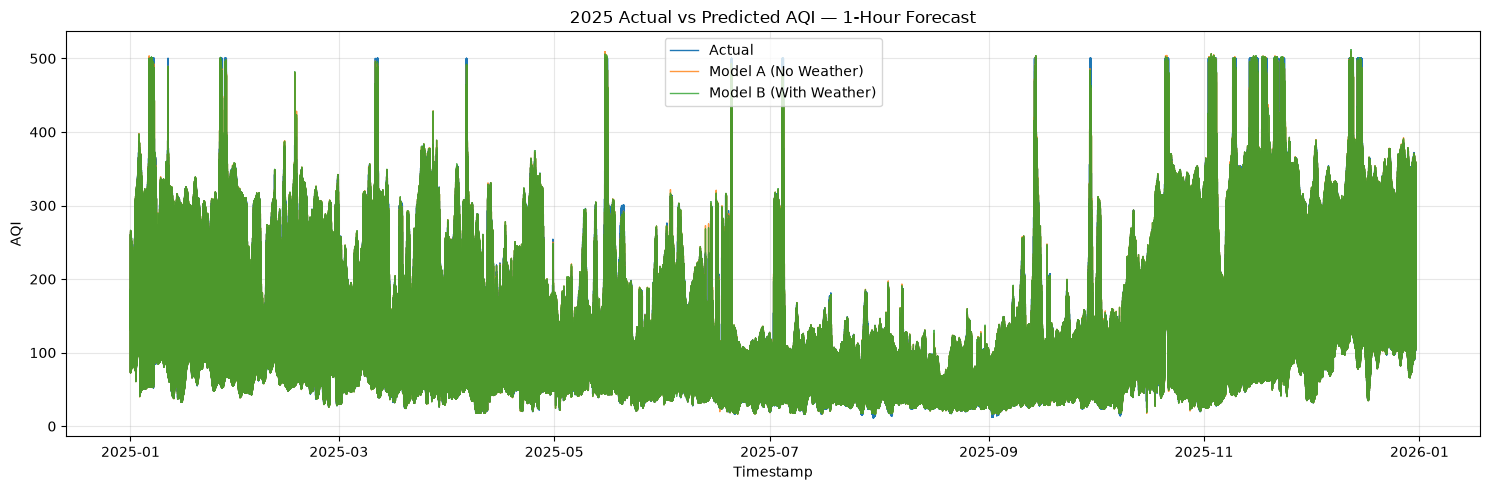

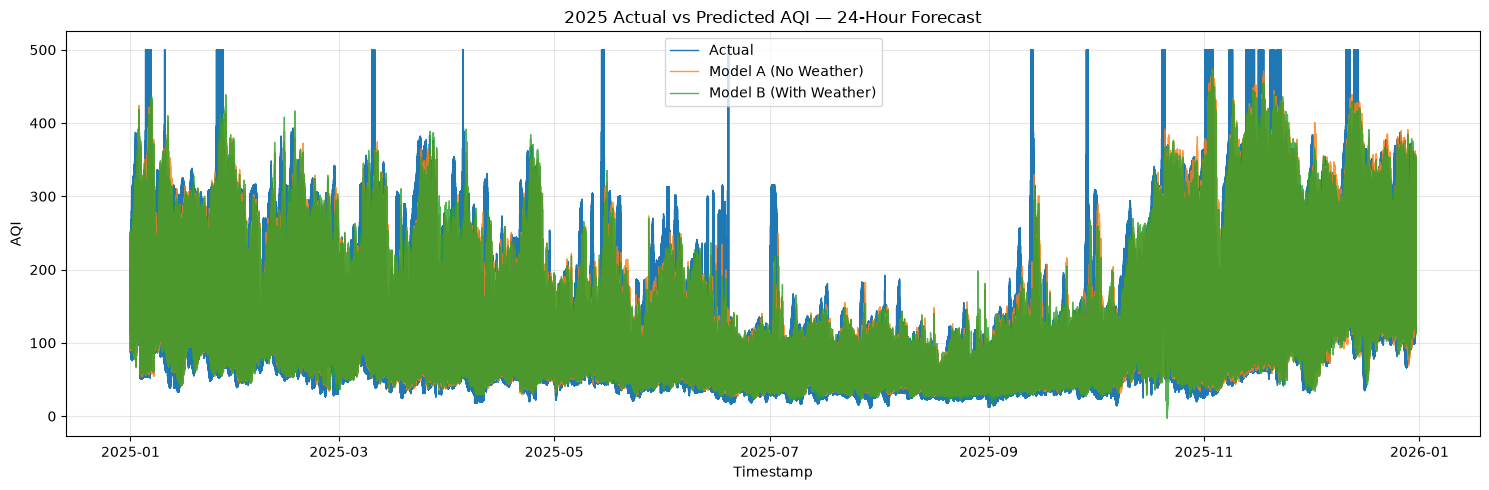

In [54]:
import matplotlib.pyplot as plt

# Sort by timestamp for a continuous time-series plot
pred_1h = pred_1h.sort_values("Timestamp").reset_index(drop=True)
pred_24h = pred_24h.sort_values("Timestamp").reset_index(drop=True)

# 1-hour forecast
plt.figure(figsize=(15, 5))
plt.plot(pred_1h["Timestamp"], pred_1h["AQI_actual"],
         label="Actual", linewidth=1)
plt.plot(pred_1h["Timestamp"], pred_1h["AQI_pred_A_no_weather"],
         label="Model A (No Weather)", alpha=0.8, linewidth=1)
plt.plot(pred_1h["Timestamp"], pred_1h["AQI_pred_B_with_weather"],
         label="Model B (With Weather)", alpha=0.8, linewidth=1)

plt.title("2025 Actual vs Predicted AQI — 1-Hour Forecast")
plt.xlabel("Timestamp")
plt.ylabel("AQI")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 24-hour forecast
plt.figure(figsize=(15, 5))
plt.plot(pred_24h["Timestamp"], pred_24h["AQI_actual"],
         label="Actual", linewidth=1)
plt.plot(pred_24h["Timestamp"], pred_24h["AQI_pred_A_no_weather"],
         label="Model A (No Weather)", alpha=0.8, linewidth=1)
plt.plot(pred_24h["Timestamp"], pred_24h["AQI_pred_B_with_weather"],
         label="Model B (With Weather)", alpha=0.8, linewidth=1)

plt.title("2025 Actual vs Predicted AQI — 24-Hour Forecast")
plt.xlabel("Timestamp")
plt.ylabel("AQI")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [55]:
import pandas as pd
import os

os.makedirs("powerbi_data", exist_ok=True)

# Standardize 1-hour predictions
p1 = pred_1h.rename(columns={
    "AQI_pred_A_no_weather": "Model_A_No_Weather",
    "AQI_pred_B_with_weather": "Model_B_With_Weather"
}).copy()

p1["Forecast_Horizon"] = "1 Hour"

# Standardize 24-hour predictions
p24 = pred_24h.rename(columns={
    "AQI_pred_A_no_weather": "Model_A_No_Weather",
    "AQI_pred_B_with_weather": "Model_B_With_Weather"
}).copy()

p24["Forecast_Horizon"] = "24 Hours"

# Combine
powerbi_df = pd.concat([p1, p24], ignore_index=True)

powerbi_df["Timestamp"] = pd.to_datetime(powerbi_df["Timestamp"])
powerbi_df["Year"] = powerbi_df["Timestamp"].dt.year
powerbi_df["Month"] = powerbi_df["Timestamp"].dt.month
powerbi_df["Month_Name"] = powerbi_df["Timestamp"].dt.strftime("%b")
powerbi_df["Date"] = powerbi_df["Timestamp"].dt.date

powerbi_df.to_csv(
    "powerbi_data/AQI_Predictions_2025_PowerBI.csv",
    index=False
)

print(powerbi_df.shape)
print(powerbi_df.head())

(375950, 9)
   Timestamp  AQI_actual  Model_A_No_Weather  Model_B_With_Weather  \
0 2025-01-01       186.0          185.341583            185.070770   
1 2025-01-01       123.0          121.373474            121.239105   
2 2025-01-01       261.0          260.651306            260.470490   
3 2025-01-01        89.0           89.632767             89.674759   
4 2025-01-01       123.0          125.246094            125.188301   

  Forecast_Horizon  Year  Month Month_Name        Date  
0           1 Hour  2025      1        Jan  2025-01-01  
1           1 Hour  2025      1        Jan  2025-01-01  
2           1 Hour  2025      1        Jan  2025-01-01  
3           1 Hour  2025      1        Jan  2025-01-01  
4           1 Hour  2025      1        Jan  2025-01-01  


In [56]:
powerbi_long = powerbi_df.melt(
    id_vars=[
        "Timestamp", "Date", "Year", "Month", "Month_Name",
        "Forecast_Horizon", "AQI_actual"
    ],
    value_vars=[
        "Model_A_No_Weather",
        "Model_B_With_Weather"
    ],
    var_name="Model",
    value_name="AQI_predicted"
)

powerbi_long["Absolute_Error"] = (
    powerbi_long["AQI_actual"] - powerbi_long["AQI_predicted"]
).abs()

powerbi_long["Residual"] = (
    powerbi_long["AQI_actual"] - powerbi_long["AQI_predicted"]
)

powerbi_long.to_csv(
    "powerbi_data/AQI_Predictions_PowerBI_Long.csv",
    index=False
)

print(powerbi_long.shape)
print(powerbi_long.head())

(751900, 11)
   Timestamp        Date  Year  Month Month_Name Forecast_Horizon  AQI_actual  \
0 2025-01-01  2025-01-01  2025      1        Jan           1 Hour       186.0   
1 2025-01-01  2025-01-01  2025      1        Jan           1 Hour       123.0   
2 2025-01-01  2025-01-01  2025      1        Jan           1 Hour       261.0   
3 2025-01-01  2025-01-01  2025      1        Jan           1 Hour        89.0   
4 2025-01-01  2025-01-01  2025      1        Jan           1 Hour       123.0   

                Model  AQI_predicted  Absolute_Error  Residual  
0  Model_A_No_Weather     185.341583        0.658417  0.658417  
1  Model_A_No_Weather     121.373474        1.626526  1.626526  
2  Model_A_No_Weather     260.651306        0.348694  0.348694  
3  Model_A_No_Weather      89.632767        0.632767 -0.632767  
4  Model_A_No_Weather     125.246094        2.246094 -2.246094  


In [ ]:
# DIRECT EVALUATION USING SAVED MODEL

import os
import numpy as np
import pandas as pd

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# --------------------------------------------------
# 1. Load saved models
# --------------------------------------------------

def load_model(path):
    model = XGBRegressor()
    model.load_model(path)
    print(f"Loaded: {path}")
    return model


model_1h_A_final = load_model("Outputs/saved_models/xgb_1h_no_weather.json")
model_1h_B_final = load_model("Outputs/saved_models/xgb_1h_with_weather.json")
model_24h_A_final = load_model("Outputs/saved_models/xgb_24h_no_weather.json")
model_24h_B_final = load_model("Outputs/saved_models/xgb_24h_with_weather.json")


# --------------------------------------------------
# 2. Match feature columns to each saved model
# --------------------------------------------------

def align_features(X, model):
    expected_features = model.get_booster().feature_names

    if expected_features is None:
        raise ValueError("The saved model does not contain feature names.")

    missing = [col for col in expected_features if col not in X.columns]

    if missing:
        raise ValueError(f"Missing required model features: {missing}")

    return X[expected_features]


X_test_1_A = align_features(X_test_1_A, model_1h_A_final)
X_test_1_B = align_features(X_test_1_B, model_1h_B_final)

X_test_24_A = align_features(X_test_24_A, model_24h_A_final)
X_test_24_B = align_features(X_test_24_B, model_24h_B_final)


# --------------------------------------------------
# 3. Generate predictions
# --------------------------------------------------

pred_1h_A = model_1h_A_final.predict(X_test_1_A)
pred_1h_B = model_1h_B_final.predict(X_test_1_B)

pred_24h_A = model_24h_A_final.predict(X_test_24_A)
pred_24h_B = model_24h_B_final.predict(X_test_24_B)


# --------------------------------------------------
# 4. Evaluate models on 2025 test data
# --------------------------------------------------

def evaluate_model(y_true, y_pred, name):
    return {
        "Forecast": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }


results = [
    evaluate_model(y_test_1, pred_1h_A, "1h Model A — No Weather"),
    evaluate_model(y_test_1, pred_1h_B, "1h Model B — With Weather"),
    evaluate_model(y_test_24, pred_24h_A, "24h Model A — No Weather"),
    evaluate_model(y_test_24, pred_24h_B, "24h Model B — With Weather")
]

metrics_df = pd.DataFrame(results)

print("\nFinal 2025 Test Results:")
display(metrics_df.round(4))


# --------------------------------------------------
# 5. Save predictions
# --------------------------------------------------

os.makedirs("predictions", exist_ok=True)

pred_1h = pd.DataFrame({
    "Timestamp": test_1["_Timestamp"].to_numpy(),
    "AQI_actual": y_test_1.to_numpy(),
    "AQI_pred_A_no_weather": pred_1h_A,
    "AQI_pred_B_with_weather": pred_1h_B
})

pred_24h = pd.DataFrame({
    "Timestamp": test_24["_Timestamp"].to_numpy(),
    "AQI_actual": y_test_24.to_numpy(),
    "AQI_pred_A_no_weather": pred_24h_A,
    "AQI_pred_B_with_weather": pred_24h_B
})

pred_1h.to_csv("predictions/predictions_2025_1h.csv", index=False)
pred_24h.to_csv("predictions/predictions_2025_24h.csv", index=False)
metrics_df.to_csv("predictions/test_metrics_2025.csv", index=False)

print("\nPrediction files saved successfully.")
print("1-hour predictions:", pred_1h.shape)
print("24-hour predictions:", pred_24h.shape)